# 05. Multilayer Perceptron (MLP)
**Algorithms implemented:** MLP with Scikit-Learn (`MLPClassifier`) and a custom PyTorch deep MLP.

**Dataset:** Handwritten digits (8x8 grayscale images, 64 features, 10 classes).


In [1]:
# ---- Core numerical and plotting libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Dataset + preprocessing/metrics ----
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# ---- Scikit-Learn MLP implementation ----
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---- PyTorch for the custom deep MLP ----
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Styling setup (consistent look across all notebooks)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

# Fix seeds for reproducible training
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)  # reproducible GPU training
np.random.seed(42)
print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # use GPU if available
print(f"Computation Device: {device}")

# ---- Load the handwritten digits dataset (8x8 grayscale images) ----
digits = load_digits()
X_raw = digits.data      # flattened images: 1797 samples x 64 pixel features
y = digits.target        # digit class 0..9

print(f"Dataset Shape: {X_raw.shape}, Target Classes: {np.unique(y)}")
# ---- Train / Validation / Test split (70% / 15% / 15%) ----
# First cut off the test set...
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_raw, y, test_size=0.15, random_state=42, stratify=y
)
# ...then split the remainder into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val
)

# ---- Feature scaling: fit on training data only (avoid validation/test leakage) ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples:   {X_train_scaled.shape[0]}")
print(f"Validation samples: {X_val_scaled.shape[0]}")
print(f"Test samples:       {X_test_scaled.shape[0]}")


PyTorch version: 2.14.0+cu126
Computation Device: cuda
Dataset Shape: (1797, 64), Target Classes: [0 1 2 3 4 5 6 7 8 9]
Training samples:   1257
Validation samples: 270
Test samples:       270


## 1. Scikit-Learn MLP

### Step-by-Step Algorithm (Multilayer Perceptron)
1. **Initialize** weights W and biases b for every layer (random small values).
2. **Forward pass:** for layer l, compute a⁽ˡ⁾ = σ(W⁽ˡ⁾a⁽ˡ⁻¹⁾ + b⁽ˡ⁾); the last layer produces class logits.
3. **Loss:** convert logits to probabilities with softmax and compute cross-entropy (plus L2 penalty).
4. **Backward pass:** use the chain rule (backpropagation) to compute the gradient of the loss w.r.t. every weight.
5. **Update:** adjust weights with an optimizer (Adam): W ← W − η·(gradient + regularization term).
6. **Repeat** steps 2–5 for many epochs over mini-batches until the loss converges.
7. **Predict:** take argmax of the output probabilities for each test sample.

### Scikit-Learn Training Process Used Here
1. Build a 64 → 128 → 64 → 10 network with ReLU activations.
2. Optimize with Adam and L2 regularization (`alpha`).
3. Use early stopping: monitor a validation split and stop when it stops improving.
4. Record the loss curve and evaluate once on the untouched test set.

Scikit-Learn MLP Test Accuracy: 0.9630
Converged after 15 iterations


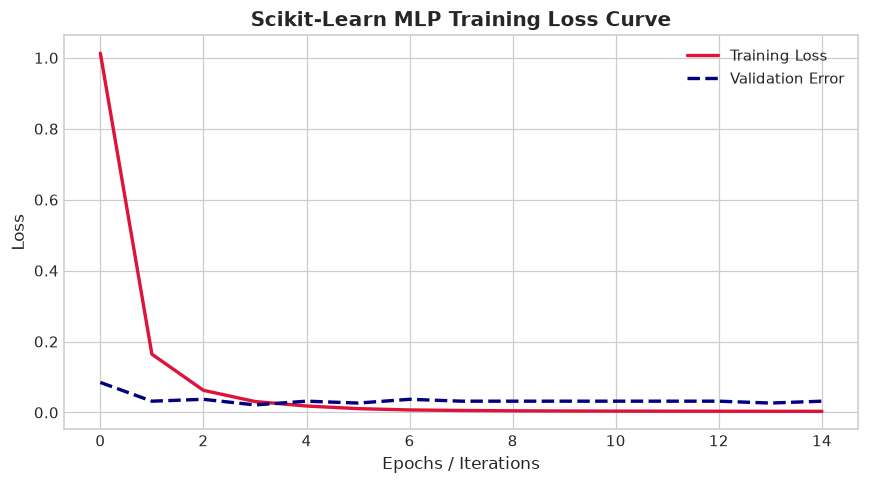

In [2]:
# ---- Scikit-Learn MLPClassifier: 64 -> 128 -> 64 -> 10 ----
mlp_sklearn = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # two hidden layers
    activation='relu',
    solver='adam',                  # adaptive gradient optimizer
    alpha=0.001,                    # L2 regularization strength
    batch_size=64,
    learning_rate_init=0.005,
    max_iter=150,
    early_stopping=True,            # stop when validation score stops improving
    validation_fraction=0.15,       # internal validation split for early stopping
    random_state=42
)

# Train (forward pass + backpropagation happen inside .fit)
mlp_sklearn.fit(X_train_scaled, y_train)

# Evaluate on the untouched test set
y_pred_sk = mlp_sklearn.predict(X_test_scaled)
acc_sk = accuracy_score(y_test, y_pred_sk)

print(f"Scikit-Learn MLP Test Accuracy: {acc_sk:.4f}")
print(f"Converged after {mlp_sklearn.n_iter_} iterations")

# ---- Plot the training loss curve recorded by scikit-learn ----
plt.figure(figsize=(8, 4.5))
plt.plot(mlp_sklearn.loss_curve_, color='crimson', lw=2.2, label='Training Loss')
if hasattr(mlp_sklearn, 'validation_scores_'):
    # validation_scores_ stores accuracy; convert to error for a comparable scale
    plt.plot([1 - s for s in mlp_sklearn.validation_scores_], color='navy', lw=2.2, linestyle='--', label='Validation Error')
plt.title("Scikit-Learn MLP Training Loss Curve", fontsize=13, fontweight='bold')
plt.xlabel("Epochs / Iterations", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


## 2. Custom PyTorch MLP

### PyTorch Training Process (explicit training loop)
1. **Data:** wrap scaled features/labels in Tensors and DataLoaders (mini-batches + shuffling).
2. **Architecture:** Linear → BatchNorm → ReLU → Dropout, twice, then a 10-unit output layer.
3. **Configure:** CrossEntropyLoss + Adam (weight decay) + ReduceLROnPlateau scheduler.
4. **For each epoch:** forward pass, compute loss, backpropagate, update weights.
5. **Monitor:** evaluate on the validation set after every epoch (no gradient updates).
6. **After training:** evaluate once on the test set, then inspect the confusion matrix and sample predictions.

In [3]:
# ---- Convert scaled NumPy arrays into PyTorch tensors + DataLoaders ----
train_dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset   = TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32),   torch.tensor(y_val, dtype=torch.long))
test_dataset  = TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32),  torch.tensor(y_test, dtype=torch.long))

# DataLoaders handle mini-batching and shuffling during training
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

class DeepMLP(nn.Module):
    """Fully-connected classifier: 64 -> 128 -> 64 -> 10 with BatchNorm + Dropout."""
    def __init__(self, in_features=64, num_classes=10):
        super(DeepMLP, self).__init__()
        self.net = nn.Sequential(
            # Hidden block 1
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128),    # stabilizes activations, speeds up training
            nn.ReLU(),              # non-linear activation
            nn.Dropout(0.25),       # regularization: randomly drop 25% of neurons

            # Hidden block 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),

            # Output layer: 10 raw logits (one per digit class)
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = DeepMLP().to(device)   # move all parameters to CPU/GPU
print(model)


DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [4]:
# ---- Training configuration ----
criterion = nn.CrossEntropyLoss()                                            # softmax + NLL loss
optimizer = optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-4)      # weight decay = L2
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

epochs = 50
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    # ---------- Training phase ----------
    model.train()                          # enable Dropout/BatchNorm training behavior
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()              # reset gradients from the previous step
        outputs = model(inputs)            # forward pass
        loss = criterion(outputs, labels)  # compute cross-entropy
        loss.backward()                    # backpropagation (compute gradients)
        optimizer.step()                   # update weights

        # Accumulate metrics (loss is averaged over the batch, so multiply by batch size)
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)   # predicted class = highest logit
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    # ---------- Validation phase ----------
    model.eval()                           # disable Dropout, use running BatchNorm stats
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():                  # no gradients needed for evaluation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    scheduler.step(epoch_val_loss)         # reduce LR if validation loss plateaus

    # Record metrics for plotting
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    # Print a progress line every 10 epochs (and the first one)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
              f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")


Epoch [01/50] Train Loss: 1.2049 | Train Acc: 0.7096 || Val Loss: 0.4564 | Val Acc: 0.9148


Epoch [10/50] Train Loss: 0.0761 | Train Acc: 0.9793 || Val Loss: 0.0846 | Val Acc: 0.9741


Epoch [20/50] Train Loss: 0.0543 | Train Acc: 0.9825 || Val Loss: 0.0821 | Val Acc: 0.9704


Epoch [30/50] Train Loss: 0.0331 | Train Acc: 0.9897 || Val Loss: 0.0361 | Val Acc: 0.9926


Epoch [40/50] Train Loss: 0.0159 | Train Acc: 0.9976 || Val Loss: 0.0511 | Val Acc: 0.9852


Epoch [50/50] Train Loss: 0.0170 | Train Acc: 0.9944 || Val Loss: 0.0414 | Val Acc: 0.9889


In [5]:
# ---- Final evaluation on the held-out test set ----
model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)          # predicted digit
        test_preds.extend(preds.cpu().numpy())    # move back to CPU for metrics
        test_targets.extend(labels.numpy())

acc_pytorch = accuracy_score(test_targets, test_preds)
print(f"PyTorch Deep MLP Test Accuracy: {acc_pytorch:.4f}\n")
print("Detailed Classification Report:")
# Per-class precision/recall/F1 for all 10 digits
print(classification_report(test_targets, test_preds, digits=4))


PyTorch Deep MLP Test Accuracy: 0.9815

Detailed Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        27
           1     0.9286    0.9630    0.9455        27
           2     1.0000    1.0000    1.0000        27
           3     1.0000    1.0000    1.0000        28
           4     0.9643    1.0000    0.9818        27
           5     0.9643    1.0000    0.9818        27
           6     1.0000    1.0000    1.0000        27
           7     0.9643    1.0000    0.9818        27
           8     1.0000    0.8846    0.9388        26
           9     1.0000    0.9630    0.9811        27

    accuracy                         0.9815       270
   macro avg     0.9821    0.9811    0.9811       270
weighted avg     0.9821    0.9815    0.9813       270

